# L02 · k-Nearest Neighbors on Gene Expression

*Companion notebook for Lecture 2 — Nearest Neighbors and Similarity (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**
1. Implement kNN classification from scratch and check it against scikit-learn.
2. See how feature scaling changes neighbors and accuracy.
3. Measure the curse of dimensionality (distance concentration).
4. Classify tumor types from 20,531-gene RNA-seq profiles, tuning $k$ and the distance by cross-validation.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from course_utils import seed_everything, plot_style, load_tcga, PALETTE

rng = seed_everything(0)
plot_style()

## 1. kNN from scratch
For a query $\mathbf x$: compute distances to all training points, take the $k$ closest, and vote.

In [2]:
def knn_predict(X_train, y_train, X_query, k=5):
    """Majority vote among the k nearest training points (Euclidean distance)."""
    # squared distances via ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a·b  (shape: n_query x n_train)
    d2 = (X_query ** 2).sum(1)[:, None] + (X_train ** 2).sum(1)[None, :] - 2 * X_query @ X_train.T
    nn = np.argsort(d2, axis=1)[:, :k]
    votes = y_train[nn]
    classes = np.unique(y_train)
    counts = np.stack([(votes == c).sum(1) for c in classes], axis=1)
    return classes[counts.argmax(1)]

# worked example from the slides: classify q = (2.5, 2.5) from five labeled points
pts = np.array([[1.0, 1.0], [2.0, 1.5], [1.5, 3.2], [4.0, 3.0], [3.5, 4.0]])
lab = np.array([0, 0, 1, 1, 1])          # 0 = ●, 1 = ■
q = np.array([2.5, 2.5])
print("distances to q:", np.round(np.linalg.norm(pts - q, axis=1), 2), " order:", np.argsort(np.linalg.norm(pts - q, axis=1)) + 1)
for k in [1, 3, 5]:
    print(f"k = {k}: predicted class {'●■'[knn_predict(pts, lab, q[None], k)[0]]}")

distances to q: [2.12 1.12 1.22 1.58 1.8 ]  order: [2 3 4 5 1]
k = 1: predicted class ●
k = 3: predicted class ■
k = 5: predicted class ■


Two interleaved half-moons (synthetic, as on the slides): 200 training points and 4,000 fresh validation points from the same distribution.

In [3]:
Xtr, ytr = make_moons(n_samples=200, noise=0.35, random_state=0)
Xte, yte = make_moons(n_samples=4000, noise=0.35, random_state=1)
for k in [1, 5, 25]:
    ours = knn_predict(Xtr, ytr, Xte, k)
    sk = KNeighborsClassifier(k).fit(Xtr, ytr).predict(Xte)
    print(f"k = {k:2d}: our validation accuracy {np.mean(ours == yte):.3f}, agreement with scikit-learn {np.mean(ours == sk):.3f}")

k =  1: our validation accuracy 0.837, agreement with scikit-learn 1.000
k =  5: our validation accuracy 0.885, agreement with scikit-learn 1.000


k = 25: our validation accuracy 0.887, agreement with scikit-learn 1.000


### Decision boundaries and model complexity

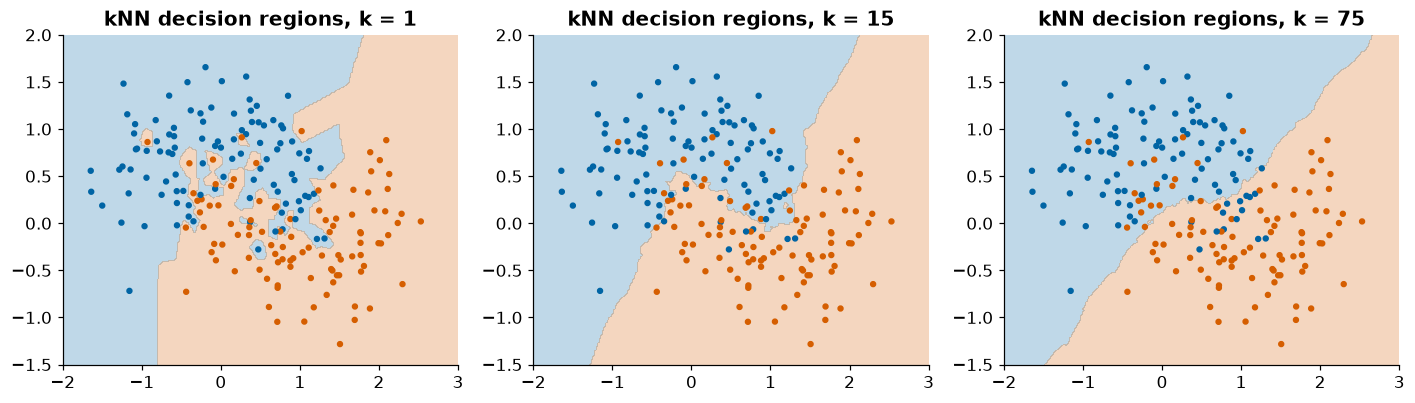

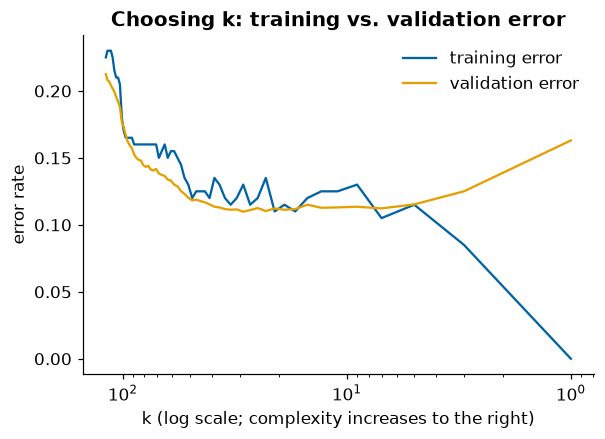

best k on the validation set: 29


In [4]:
gx, gy = np.meshgrid(np.linspace(-2, 3, 250), np.linspace(-1.5, 2, 250))
G = np.c_[gx.ravel(), gy.ravel()]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, k in zip(axes, [1, 15, 75]):
    Z = knn_predict(Xtr, ytr, G, k).reshape(gx.shape)
    ax.contourf(gx, gy, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5], colors=[PALETTE[0], PALETTE[5]])
    ax.scatter(*Xtr.T, c=np.where(ytr, PALETTE[5], PALETTE[0]), s=10)
    ax.set_title(f"kNN decision regions, k = {k}")
plt.tight_layout(); plt.show()

ks = np.arange(1, 121, 2)
train_err = [1 - KNeighborsClassifier(k).fit(Xtr, ytr).score(Xtr, ytr) for k in ks]
val_err = [1 - KNeighborsClassifier(k).fit(Xtr, ytr).score(Xte, yte) for k in ks]
plt.semilogx(ks, train_err, label="training error"); plt.semilogx(ks, val_err, label="validation error")
plt.xlabel("k (log scale; complexity increases to the right)"); plt.ylabel("error rate")
plt.title("Choosing k: training vs. validation error"); plt.gca().invert_xaxis(); plt.legend(); plt.show()
print("best k on the validation set:", ks[int(np.argmin(val_err))])

## 2. Feature scaling: breast-cancer biopsies
The 30 nucleus features have very different units (area ≈ hundreds, smoothness ≈ 0.1). Without scaling, a few large-valued features dominate the Euclidean distance.

In [5]:
bc = load_breast_cancer()
Xb, yb = bc.data, 1 - bc.target   # 1 = malignant
cv = StratifiedKFold(5, shuffle=True, random_state=0)
for k in [1, 5, 15]:
    raw = cross_val_score(KNeighborsClassifier(k), Xb, yb, cv=cv).mean()
    std = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(k)), Xb, yb, cv=cv).mean()
    print(f"k = {k:2d}: raw features {raw:.3f}   standardized {std:.3f}")

k =  1: raw features 0.914   standardized 0.958


k =  5: raw features 0.932   standardized 0.965
k = 15: raw features 0.928   standardized 0.961


`make_pipeline(StandardScaler(), ...)` refits the scaler inside each training fold, so no information from the validation fold leaks into the scaling.

## 3. The curse of dimensionality
With uniform random data, the nearest and farthest neighbors become almost equally far as the dimension grows.

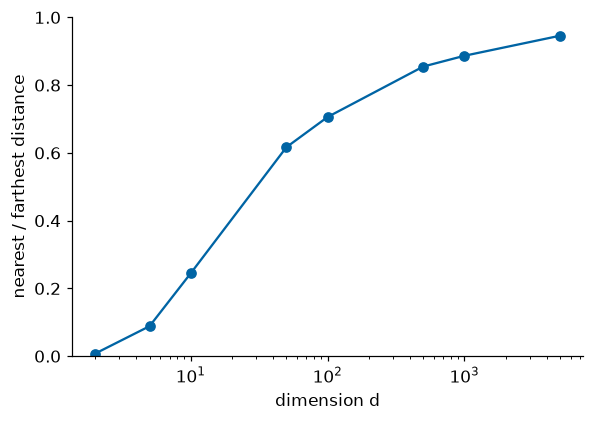

d =    1: edge of the cube holding 10 of 1000 uniform points ≈ 0.010
d =    2: edge of the cube holding 10 of 1000 uniform points ≈ 0.100
d =   10: edge of the cube holding 10 of 1000 uniform points ≈ 0.631
d =  100: edge of the cube holding 10 of 1000 uniform points ≈ 0.955
d = 1000: edge of the cube holding 10 of 1000 uniform points ≈ 0.995


In [6]:
dims = [2, 5, 10, 50, 100, 500, 1000, 5000]
ratios = []
for d in dims:
    P = rng.uniform(size=(1000, d)); q = rng.uniform(size=d)
    dist = np.linalg.norm(P - q, axis=1)
    ratios.append(dist.min() / dist.max())
plt.semilogx(dims, ratios, "o-"); plt.xlabel("dimension d"); plt.ylabel("nearest / farthest distance")
plt.ylim(0, 1); plt.show()

k, n = 10, 1000
for d in [1, 2, 10, 100, 1000]:
    print(f"d = {d:4d}: edge of the cube holding {k} of {n} uniform points ≈ {(k / n) ** (1 / d):.3f}")

## 4. Application: tumor type from gene expression

**Data.** The UCI "Gene expression cancer RNA-Seq" dataset: an extract of The Cancer Genome Atlas (TCGA) Pan-Cancer RNA-seq data (Weinstein et al., *Nature Genetics* 2013).
- **One sample** = one tumor ($n = 801$). **Features** = 20,531 genes; values are log-scale normalized expression. Gene names are anonymized in this extract (`gene_0`, `gene_1`, …), so we cannot interpret individual genes here.
- **Target** = tumor type: BRCA (breast), COAD (colon), KIRC (kidney), LUAD (lung), PRAD (prostate).

- Source: Fiorini S., *Gene expression cancer RNA-Seq*, UCI Machine Learning Repository (2016), doi:10.24432/C5R88H, license CC BY 4.0. The breast-biopsy data above (Wolberg et al., UCI, CC BY 4.0) ship with scikit-learn.

The first run downloads about 70 MB from the UCI repository and caches it in `applications/data/`.

In [7]:
X, y, genes = load_tcga()
print("X:", X.shape, " genes such as", genes[:3])
types, counts = np.unique(y, return_counts=True)
print({str(t): int(c) for t, c in zip(types, counts)})

X: (801, 20531)  genes such as ['gene_0' 'gene_1' 'gene_2']
{'BRCA': 300, 'COAD': 78, 'KIRC': 146, 'LUAD': 141, 'PRAD': 136}


### Exploration
How different are tumors of different types compared to tumors of the same type? Compare correlation distances within and between types.

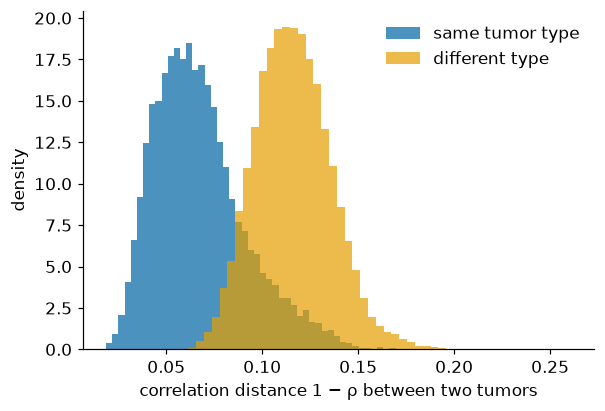

In [8]:
idx = rng.choice(len(X), 300, replace=False)
C = np.corrcoef(X[idx])
same = (y[idx][:, None] == y[idx][None, :]) & ~np.eye(len(idx), dtype=bool)
diff = y[idx][:, None] != y[idx][None, :]
plt.hist(1 - C[same], bins=50, alpha=0.7, density=True, label="same tumor type")
plt.hist(1 - C[diff], bins=50, alpha=0.7, density=True, label="different type")
plt.xlabel("correlation distance 1 − ρ between two tumors"); plt.ylabel("density"); plt.legend(); plt.show()

### Split, then tune $k$ and the distance by cross-validation on the training set only

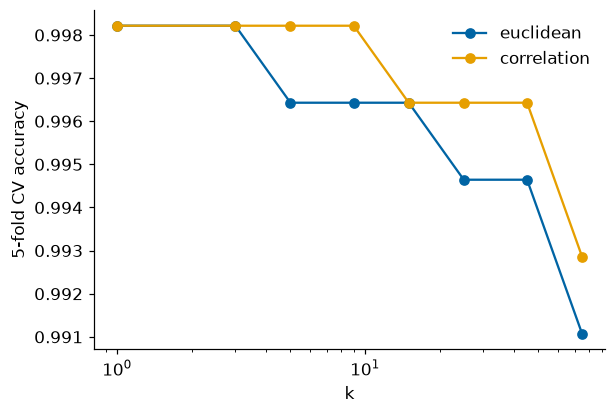

euclidean    k=1: 0.998  k=3: 0.998  k=5: 0.996  k=9: 0.996  k=15: 0.996  k=25: 0.995  k=45: 0.995  k=75: 0.991
correlation  k=1: 0.998  k=3: 0.998  k=5: 0.998  k=9: 0.998  k=15: 0.996  k=25: 0.996  k=45: 0.996  k=75: 0.993
chosen: correlation k = 1


In [9]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
cv = StratifiedKFold(5, shuffle=True, random_state=0)
ks = [1, 3, 5, 9, 15, 25, 45, 75]
results = {}
for metric in ["euclidean", "correlation"]:
    results[metric] = [cross_val_score(KNeighborsClassifier(k, metric=metric, algorithm="brute"),
                                       Xtr, ytr, cv=cv).mean() for k in ks]
    plt.semilogx(ks, results[metric], "o-", label=metric)
plt.xlabel("k"); plt.ylabel("5-fold CV accuracy"); plt.legend(); plt.show()
# pick the best (metric, k); on ties prefer correlation distance, as on the slides
best_metric = max(results, key=lambda m: (max(results[m]), m == "correlation"))
best_k = ks[int(np.argmax(results[best_metric]))]   # np.argmax takes the smallest k on ties
for metric in results:
    print(f"{metric:12s}", "  ".join(f"k={k}: {a:.3f}" for k, a in zip(ks, results[metric])))
print("chosen:", best_metric, "k =", best_k)

Accuracy dips for large $k$. Where do those cross-validation errors go? (Same folds, correlation distance, $k = 75$.)

In [10]:
k_large = 75
p_cv = cross_val_predict(KNeighborsClassifier(k_large, metric="correlation", algorithm="brute"), Xtr, ytr, cv=cv)
bad = p_cv != ytr
print(f"k = {k_large}: {bad.sum()} CV errors, {(p_cv[bad] == 'BRCA').sum()} of them predicted as BRCA")
for t, p_ in zip(ytr[bad], p_cv[bad]):
    print(f"  true {t} -> predicted {p_}")

k = 75: 4 CV errors, 4 of them predicted as BRCA
  true LUAD -> predicted BRCA
  true COAD -> predicted BRCA
  true LUAD -> predicted BRCA
  true KIRC -> predicted BRCA


The errors are tumors predicted as **BRCA**, the largest class (300 of 801 tumors): a large neighborhood contains many BRCA tumors, so BRCA wins more votes. Distance-weighted or class-balanced voting counteracts this.

### Evaluation on the held-out test tumors

test accuracy = 1.000 (241 / 241)
majority-class baseline = 0.373


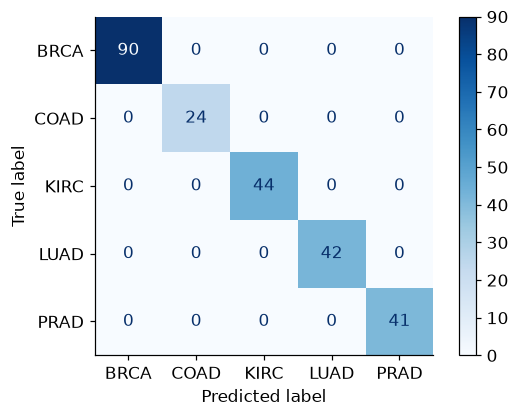

95% confidence interval for accuracy: [0.985, 1.000]


In [11]:
clf = KNeighborsClassifier(best_k, metric=best_metric, algorithm="brute").fit(Xtr, ytr)
pred = clf.predict(Xte)
acc = np.mean(pred == yte)
print(f"test accuracy = {acc:.3f} ({(pred == yte).sum()} / {len(yte)})")
print(f"majority-class baseline = {np.mean(yte == 'BRCA'):.3f}")
ConfusionMatrixDisplay.from_predictions(yte, pred, cmap="Blues"); plt.show()

# exact (Clopper–Pearson) 95% interval for the accuracy
from scipy.stats import beta
x, m = (pred == yte).sum(), len(yte)
lo = beta.ppf(0.025, x, m - x + 1) if x > 0 else 0.0
hi = beta.ppf(0.975, x + 1, m - x) if x < m else 1.0
print(f"95% confidence interval for accuracy: [{lo:.3f}, {hi:.3f}]")

### Which neighbors does kNN use?
For a few test tumors, list the tumor types of their nearest training neighbors and the distances.

In [12]:
dist, nbr = KNeighborsClassifier(5, metric="correlation", algorithm="brute").fit(Xtr, ytr).kneighbors(Xte[:5])
for i in range(5):
    print(f"test tumor ({yte[i]}): neighbors {[str(t) for t in ytr[nbr[i]]]}, distances {np.round(dist[i], 3)}")

test tumor (KIRC): neighbors ['KIRC', 'KIRC', 'KIRC', 'KIRC', 'KIRC'], distances [0.023 0.025 0.026 0.026 0.026]
test tumor (PRAD): neighbors ['PRAD', 'PRAD', 'PRAD', 'PRAD', 'PRAD'], distances [0.027 0.027 0.027 0.027 0.027]
test tumor (BRCA): neighbors ['BRCA', 'BRCA', 'BRCA', 'BRCA', 'BRCA'], distances [0.041 0.043 0.043 0.043 0.044]
test tumor (LUAD): neighbors ['LUAD', 'LUAD', 'LUAD', 'LUAD', 'LUAD'], distances [0.047 0.049 0.049 0.051 0.051]
test tumor (BRCA): neighbors ['BRCA', 'BRCA', 'BRCA', 'BRCA', 'BRCA'], distances [0.048 0.053 0.055 0.056 0.056]


## 5. Biological interpretation
- Tumors of the same tissue have much more similar genome-wide expression than tumors of different tissues. This is why tissue of origin is an easy target even for kNN with all 20,531 genes.
- kNN does not tell us *which* genes matter. Lecture 5 uses sparse (L1-regularized) models to pick a small gene signature.
- All tumors come from one consortium's pipeline. Samples from a different lab or sequencing protocol could look systematically different (batch effects; Lecture 6).

## 6. Try it yourself
1. Change k from 1 to 75. Which tumor types are confused first? (Change `k_large` in the large-$k$ cell, e.g. 25, 45, 75, 150, and inspect the true → predicted pairs.)
2. Use only the 500 most variable genes (chosen on training data). Better or worse? Why must the variance be computed on training data only? (`top = np.argsort(Xtr.var(0))[-500:]`, then use `Xtr[:, top]` and `Xte[:, top]`.)
3. Drop standardization on the biopsy data for different k. (The scaling cell prints both; add more values of k, e.g. 25 and 75.)
4. Use Euclidean distance on TCGA with and without standardizing genes. Which is better here, and why might standardizing many low-expressed genes hurt?
5. *(CS284A)* Implement distance-weighted voting (weights $1/\mathrm{dist}$) and compare on the moons data with $k=25$.